# **AQI Based Factory Placement Recommendation System**

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error

# **Data Loading & Exploration**

In [36]:
# Load dataset
df = pd.read_csv("/content/INDIA_AQI_COMPLETE_20251126.csv", encoding="latin1")
df.head()

,City,State,Latitude,Longitude,Datetime,Year,Month,Day,Hour,Day_of_Week,...,US_AQI_CO,EU_AQI,EU_AQI_PM25,EU_AQI_PM10,AQI_Category,PM25_Category_India,Temp_Inversion,Inversion_Strength_C,Festival_Period,Crop_Burning_Season
0,Agartala,Tripura,23.8315,91.2868,2022-08-05 00:00:00,2022,8,5,0,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
1,Agartala,Tripura,23.8315,91.2868,2022-08-05 01:00:00,2022,8,5,1,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
2,Agartala,Tripura,23.8315,91.2868,2022-08-05 02:00:00,2022,8,5,2,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
3,Agartala,Tripura,23.8315,91.2868,2022-08-05 03:00:00,2022,8,5,3,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
4,Agartala,Tripura,23.8315,91.2868,2022-08-05 04:00:00,2022,8,5,4,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0


In [37]:
df.shape

(842160, 71)

In [38]:
# Dropping unimportant columns
df = df.drop(columns=['State', 'Latitude', 'Longitude', 'Datetime','Season','Day', 'Hour', 'Day_of_Week', 'Year', 'Month','Day_Name', 'Week_of_Year', 'Is_Weekend',
       'Quarter', 'Time_of_Day', 'Temp_80m_C',
       'Temp_120m_C', 'Temp_180m_C','Dew_Point_C',
       'Humidity_Category', 'Wind_Speed_10m_kmh', 'Wind_Speed_80m_kmh',
       'Wind_Speed_120m_kmh', 'Wind_Dir_10m', 'Wind_Gusts_kmh',
       'Wind_Category', 'Wind_Stagnation', 'Precipitation_mm', 'Rain_mm',
       'Is_Raining', 'Heavy_Rain', 'Pressure_MSL_hPa', 'Surface_Pressure_hPa',
       'Solar_Radiation_Wm2', 'Direct_Radiation_Wm2', 'Diffuse_Radiation_Wm2',
       'UV_Index', 'Cloud_Cover_Percent', 'Cloud_Low_Percent',
       'Cloud_Mid_Percent', 'Cloud_High_Percent', 'Is_Daytime',
       'Sunshine_Seconds', 'PM_Ratio','Dust_ugm3','NH3_ugm3', 'AOD','US_AQI_PM25', 'US_AQI_PM10', 'US_AQI_NO2', 'US_AQI_O3',
       'US_AQI_CO', 'EU_AQI', 'EU_AQI_PM25', 'EU_AQI_PM10','PM25_Category_India', 'Temp_Inversion', 'Inversion_Strength_C',
       'Festival_Period', 'Crop_Burning_Season','AQI_Category'])
df

,City,Temp_2m_C,Humidity_Percent,PM2_5_ugm3,PM10_ugm3,CO_ugm3,NO2_ugm3,SO2_ugm3,O3_ugm3,US_AQI
0,Agartala,26.7,91,14.8,21.5,197.0,21.8,2.7,32.0,NaN
1,Agartala,26.4,93,15.7,22.8,196.0,18.5,3.0,33.0,NaN
2,Agartala,26.1,95,16.3,23.5,196.0,15.1,3.3,34.0,NaN
3,Agartala,26.0,96,17.6,25.4,197.0,14.1,3.3,32.0,NaN
4,Agartala,25.8,97,18.2,26.2,199.0,13.9,3.2,30.0,NaN
...,...,...,...,...,...,...,...,...,...,...
842155,Visakhapatnam,25.0,68,84.5,87.8,1126.0,18.1,38.5,155.0,172.0
842156,Visakhapatnam,24.6,69,81.3,84.8,1213.0,17.4,34.9,152.0,172.0
842157,Visakhapatnam,23.6,74,77.8,81.0,1279.0,17.2,30.9,146.0,171.0
842158,Visakhapatnam,22.5,80,74.5,78.0,1332.0,17.1,26.7,138.0,170.0


In [39]:
# Checking unique values
for i in df.columns:
  print("Column :",i)
  print(df[i].unique())
  print("-"*50)

Column : City
['Agartala' 'Ahmedabad' 'Aizawl' 'Bengaluru' 'Bhopal' 'Bhubaneswar'
 'Chandigarh' 'Chennai' 'Dehradun' 'Delhi' 'Gangtok' 'Gurugram' 'Guwahati'
 'Hyderabad' 'Imphal' 'Itanagar' 'Jaipur' 'Kohima' 'Kolkata' 'Lucknow'
 'Mumbai' 'Panaji' 'Patna' 'Raipur' 'Ranchi' 'Shillong' 'Shimla'
 'Thiruvananthapuram' 'Visakhapatnam']
--------------------------------------------------
Column : Temp_2m_C
[ 26.7  26.4  26.1  26.   25.8  26.6  27.9  29.3  30.4  31.2  31.9  32.4
  32.8  33.3  33.4  32.9  30.3  29.5  28.2  28.   27.7  27.5  27.   25.9
  25.7  27.4  29.1  30.2  31.6  32.3  31.8  30.8  28.3  28.1  27.6  27.3
  26.3  26.2  29.4  30.7  31.7  32.5  33.   33.5  33.7  33.6  29.8  28.8
  28.4  27.8  27.2  26.5  32.7  33.2  30.9  26.9  26.8  25.6  27.1  29.9
  31.1  32.6  31.3  31.   28.5  29.6  30.6  30.1  29.7  29.   25.4  28.9
  30.   29.2  28.7  32.1  28.6  25.2  31.4  25.3  30.5  32.2  33.1  33.8
  34.7  35.7  36.3  36.8  36.6  36.2  31.5  32.   25.5  25.   24.9  24.7
  25.1  33.9  

# **Handling Null Values**

In [40]:
# Checking Null Values
df.isnull().sum()

,0
City,0
Temp_2m_C,0
Humidity_Percent,0
PM2_5_ugm3,0
PM10_ugm3,0
CO_ugm3,0
NO2_ugm3,0
SO2_ugm3,0
O3_ugm3,0
US_AQI,145


In [41]:
# Dropping null values
df.dropna(inplace=True)

# **Handling Duplicated values**

In [42]:
# Checking Duplicated Values
df.duplicated().sum()

np.int64(2)

In [43]:
# Dropping Duplicated values
df.drop_duplicates(inplace=True)

In [44]:
# Checking shape after dropping null & Duplicated values
df.shape

(842013, 10)

# **Renaming Column names**

In [45]:
# Renaming Column name
df.rename(columns={"Temp_2m_C":"Temperature","Humidity_Percent":"Humidity","PM2_5_ugm3":"PM2.5","PM10_ugm3":"PM10",
                   "CO_ugm3":"CO","NO2_ugm3":"NO2","SO2_ugm3":"SO2","O3_ugm3":"O3","US_AQI":"AQI"}, inplace=True)
df

,City,Temperature,Humidity,PM2.5,PM10,CO,NO2,SO2,O3,AQI
5,Agartala,26.6,95,19.1,27.6,210.0,16.4,3.5,26.0,54.0
6,Agartala,27.9,89,16.2,23.6,197.0,15.6,3.6,31.0,55.0
7,Agartala,29.3,82,12.0,17.7,180.0,14.5,3.7,39.0,55.0
8,Agartala,30.4,78,10.1,14.9,160.0,12.8,3.6,50.0,55.0
9,Agartala,31.2,73,10.9,16.1,153.0,10.9,3.2,60.0,54.0
...,...,...,...,...,...,...,...,...,...,...
842155,Visakhapatnam,25.0,68,84.5,87.8,1126.0,18.1,38.5,155.0,172.0
842156,Visakhapatnam,24.6,69,81.3,84.8,1213.0,17.4,34.9,152.0,172.0
842157,Visakhapatnam,23.6,74,77.8,81.0,1279.0,17.2,30.9,146.0,171.0
842158,Visakhapatnam,22.5,80,74.5,78.0,1332.0,17.1,26.7,138.0,170.0


# **Checking and correcting DataTypes**

In [46]:
# Checking Data Types
df.dtypes

,0
City,object
Temperature,float64
Humidity,int64
PM2.5,float64
PM10,float64
CO,float64
NO2,float64
SO2,float64
O3,float64
AQI,float64


In [47]:
df['AQI']= df['AQI'].astype(int)
df.dtypes

,0
City,object
Temperature,float64
Humidity,int64
PM2.5,float64
PM10,float64
CO,float64
NO2,float64
SO2,float64
O3,float64
AQI,int64


# **Visualization**

<Axes: >

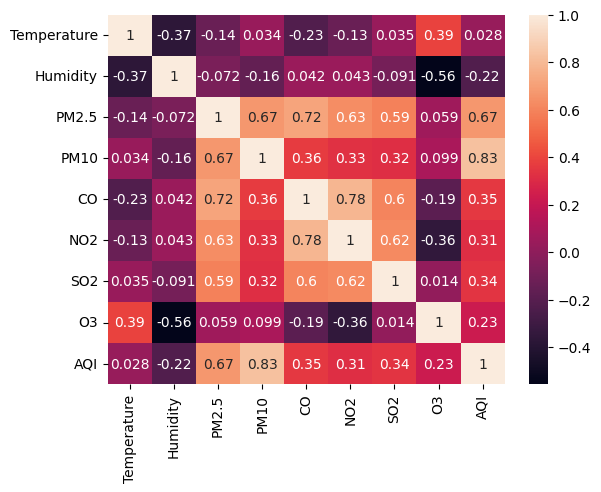

In [48]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

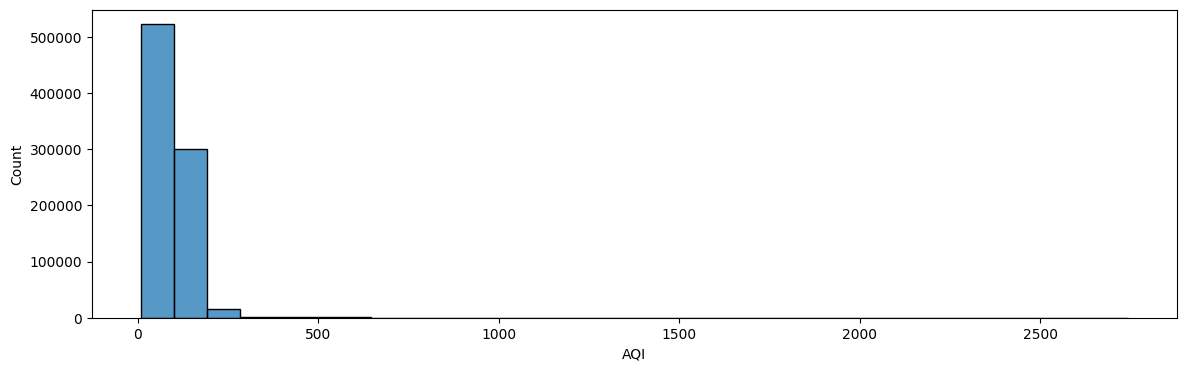

In [49]:
plt.figure(figsize=(14,4))
sns.histplot(df['AQI'],bins=30)
plt.show()

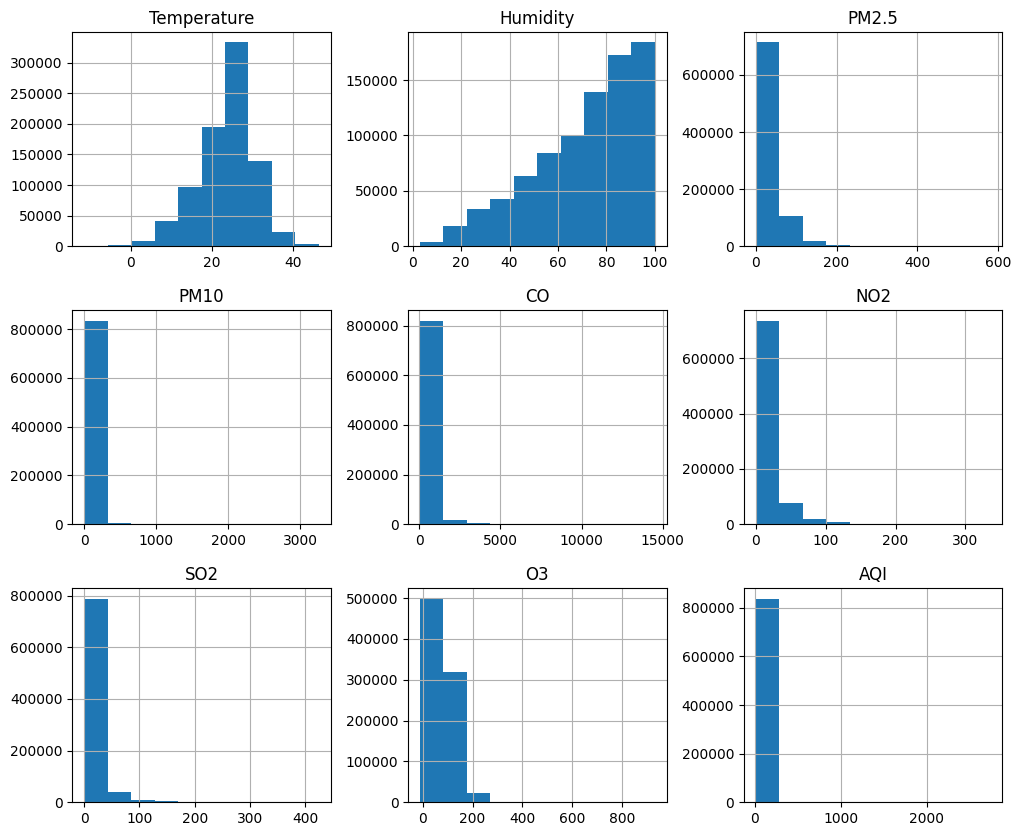

In [50]:
df.hist(figsize=(12,10))
plt.show()

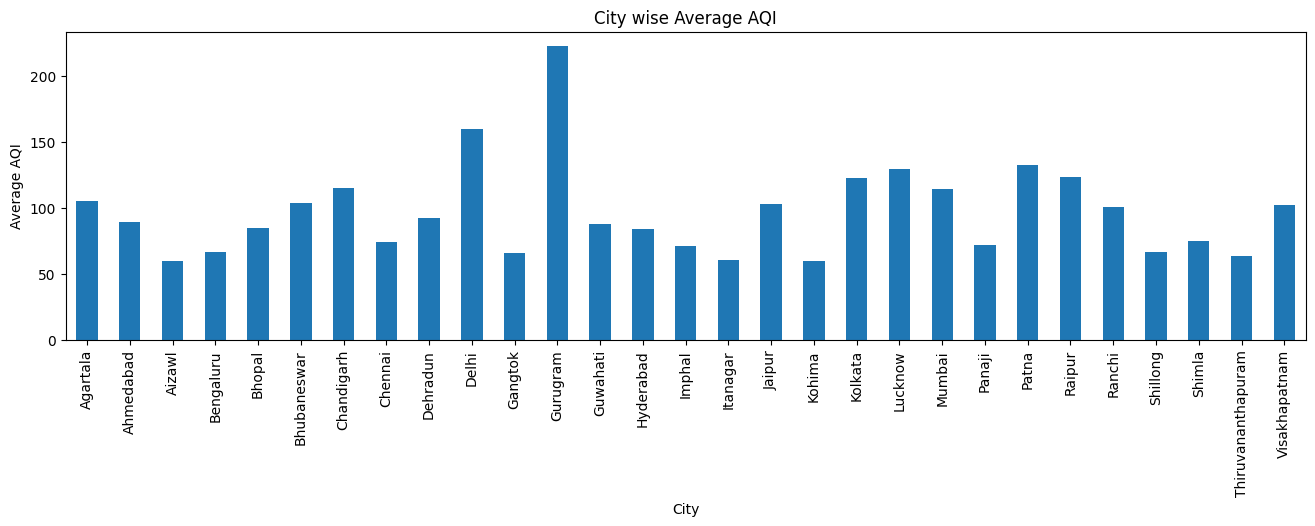

In [51]:
city_aqi = df.groupby("City")['AQI'].mean()
city_aqi.plot(kind='bar', figsize=(16,4))
plt.title("City wise Average AQI")
plt.ylabel("Average AQI")
plt.show()

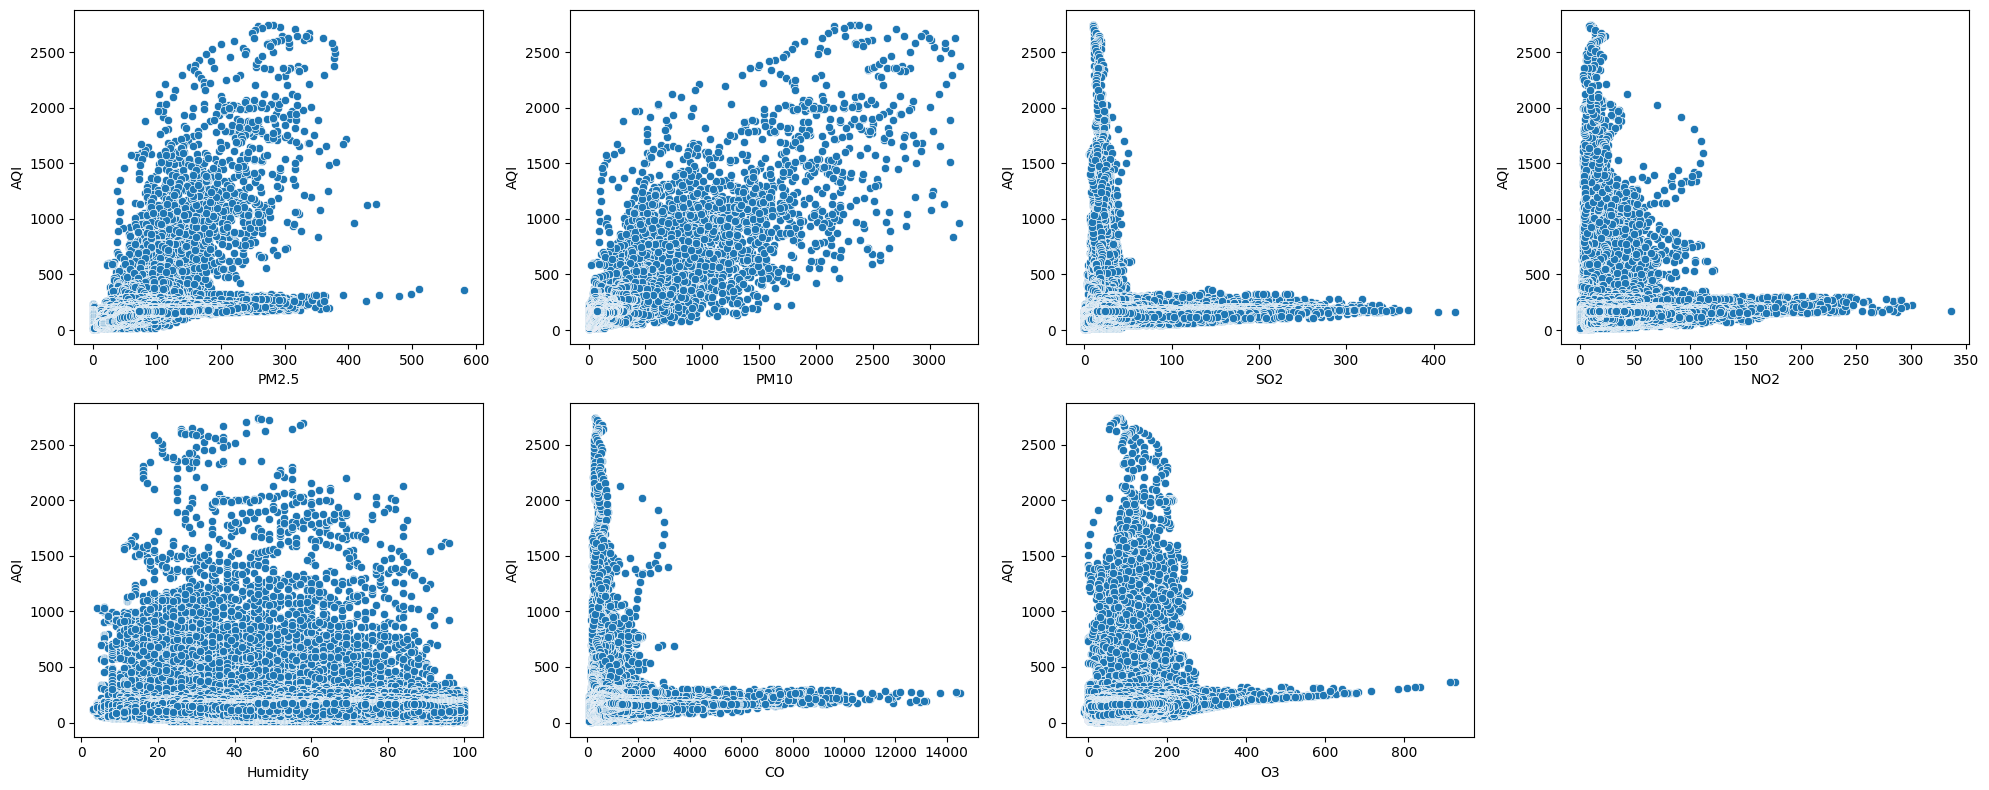

In [52]:
plt.figure(figsize=(20,8))
plt.subplot(2,4,1)
sns.scatterplot(x=df['PM2.5'], y=df['AQI'])

plt.subplot(2,4,2)
sns.scatterplot(x=df['PM10'], y=df['AQI'])

plt.subplot(2,4,3)
sns.scatterplot(x=df['SO2'], y=df['AQI'])

plt.subplot(2,4,4)
sns.scatterplot(x=df['NO2'], y=df['AQI'])

plt.subplot(2,4,5)
sns.scatterplot(x=df['Humidity'], y=df['AQI'])

plt.subplot(2,4,6)
sns.scatterplot(x=df['CO'], y=df['AQI'])

plt.subplot(2,4,7)
sns.scatterplot(x=df['O3'], y=df['AQI'])

plt.tight_layout()
plt.show()

# **Take Sample of 150k rows as Data is too large**

In [53]:
sample = df.sample(n = 150000, random_state = 40)
sample.shape

(150000, 10)

# **Divide data in X & Y**

In [54]:
x = sample.drop(["AQI","City"],axis=1)
y = sample["AQI"]

# **Train Test & Split**

In [55]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 40)

# **Standardizing the data**

In [56]:
scale = StandardScaler()
x_train_scaled = scale.fit_transform(x_train)
x_test_scaled = scale.fit_transform(x_test)

# **Train Multiple Regression Model**

In [62]:
models = {
    "Linear Regression" : LinearRegression(),
    "Ridge" : Ridge(),
    "Random Forest" : RandomForestRegressor(random_state=42),
    "Decision Tree" : DecisionTreeRegressor(),
    "KNN" : KNeighborsRegressor(),
    "SVM" : SVR()
}

for name, model in models.items():
  model.fit(x_train_scaled, y_train)
  pred = model.predict(x_test_scaled)
  r2 = r2_score(y_test, pred)
  mae = mean_absolute_error(y_test, pred)

  print(name,":",r2,",",round(mae,2))


Linear Regression : 0.7004719737881213 , 19.33
Ridge : 0.7004728114378292 , 19.33
Random Forest : 0.786363627176534 , 14.34
Decision Tree : 0.4958957970408343 , 20.41
KNN : 0.7643532573047538 , 14.41
SVM : 0.4801114499647199 , 15.3


# **Hyper Parameter Tuning**

### **Random Forest**

In [63]:
rf = RandomForestRegressor()

param_random = {
    "n_estimators":[50,80,100,120],
    "max_depth": [4,6,8,10,None],
    "min_samples_split": [2,5,8,10],
    "min_samples_leaf":[1,2,4,5]
}

random = RandomizedSearchCV(
    estimator = rf,
    param_distributions=param_random,
    n_iter=10,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

random.fit(x_train_scaled,y_train)
print(random.best_params_)
best_random = random.best_estimator_
y_pred = best_random.predict(x_test_scaled)
print("r2 Score :", r2_score(y_test,y_pred))
print("MAE :", mean_absolute_error(y_test,y_pred))

{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10}
r2 Score : 0.7794210545406349
MAE : 14.73312713778963


### **KNN**

In [64]:
knn = KNeighborsRegressor()

param_knn = {
    "n_neighbors" : [3,5,7,9],
    "weights" : ["uniform", "distance"],
    "p" : [1,2] # 1 = Manhattan , 2 = Euclidean
}

knn_search = RandomizedSearchCV(
    knn,
    param_knn,
    n_iter = 5,
    cv = 2,
    scoring = "r2",
    n_jobs = -1,
    random_state = 42
)

knn_search.fit(x_train_scaled,y_train)
print(knn_search.best_params_)
best_knn = knn_search.best_estimator_
y_pred = best_knn.predict(x_test_scaled)
print("r2 Score :", r2_score(y_test,y_pred))
print("MAE :", mean_absolute_error(y_test,y_pred))

{'weights': 'distance', 'p': 1, 'n_neighbors': 9}
r2 Score : 0.7786378124204025
MAE : 13.865176983645288


### **Ridge**

In [65]:
ridge = Ridge()

param_ridge = {
    "alpha" : [0.01,0.1,1,10,50,100]
}

ridge_search = RandomizedSearchCV(
    ridge,
    param_ridge,
    n_iter = 4,
    cv = 5,
    scoring = "r2",
    random_state=42
)

ridge_search.fit(x_train_scaled,y_train)
print(ridge_search.best_params_)
best_ridge = ridge_search.best_estimator_
y_pred = best_ridge.predict(x_test_scaled)
print("r2 Score :", r2_score(y_test,y_pred))
print("MAE :", mean_absolute_error(y_test,y_pred))

{'alpha': 100}
r2 Score : 0.7005550570276174
MAE : 19.33026418922756


# **Making Random Forest Model**

In [66]:
random_forest = RandomForestRegressor(random_state=42, n_estimators=50,max_depth=10)
random_forest.fit(x_train_scaled,y_train)
y_pred = random_forest.predict(x_test_scaled)
print("r2 Score :", r2_score(y_test,y_pred))
print("MAE :", mean_absolute_error(y_test,y_pred))

r2 Score : 0.7721986918497434
MAE : 15.132397526078325


# **Take input from user and Predict AQI**

In [67]:
import numpy as np
input = np.array([[35,88,75,50,300,50,7.9,7.5]])
input_scaled = scale.transform(input)
input_pred = random_forest.predict(input_scaled)
print(input_pred[0])

136.5774439265137


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# **RandomForest Model pkl file**

In [68]:
import joblib
joblib.dump(random_forest,"aqi_model.pkl") #create = dump

['aqi_model.pkl']

In [69]:
from google.colab import files
files.download("aqi_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Scalling pkl file**

In [70]:
joblib.dump(scale,"scale.pkl")

['scale.pkl']

In [71]:
files.download("scale.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **City Avg Features pkl file**

In [72]:
city_avg_feature = df.groupby("City")[['Temperature', 'Humidity', 'PM2.5', 'PM10',
                                       'CO', 'O3', 'AQI','SO2', 'NO2']].mean()

joblib.dump(city_avg_feature, "city_avg_feature.pkl")

['city_avg_feature.pkl']

In [73]:
from google.colab import files
files.download("city_avg_feature.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>